In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
df = pd.read_csv('/content/Airline Passenger Satisfaction Classification (data set).csv')
df

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,1,Male,48,First-time,Business,Business,821,2,5.0,3,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,Female,35,Returning,Business,Business,821,26,39.0,2,...,5,4,5,5,3,5,2,5,5,Satisfied
2,3,Male,41,Returning,Business,Business,853,0,0.0,4,...,3,5,3,5,5,3,4,3,3,Satisfied
3,4,Male,50,Returning,Business,Business,1905,0,0.0,2,...,5,5,5,4,4,5,2,5,5,Satisfied
4,5,Female,49,Returning,Business,Business,3470,0,1.0,3,...,3,4,4,5,4,3,3,3,3,Satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14996,Female,23,Returning,Business,Economy,1201,0,0.0,5,...,2,4,4,3,3,2,0,3,2,Satisfied
14996,14997,Male,22,Returning,Business,Business,2458,0,7.0,2,...,3,4,3,4,4,3,4,4,4,Neutral or Dissatisfied
14997,14998,Male,53,Returning,Business,Economy,1201,3,0.0,2,...,1,1,5,1,1,4,2,1,3,Neutral or Dissatisfied
14998,14999,Female,68,Returning,Business,Business,1201,0,0.0,2,...,4,5,4,5,5,4,2,4,4,Satisfied


In [2]:
df.shape

(15000, 24)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 24 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   ID                                      15000 non-null  int64  
 1   Gender                                  15000 non-null  object 
 2   Age                                     15000 non-null  int64  
 3   Customer Type                           15000 non-null  object 
 4   Type of Travel                          15000 non-null  object 
 5   Class                                   15000 non-null  object 
 6   Flight Distance                         15000 non-null  int64  
 7   Departure Delay                         15000 non-null  int64  
 8   Arrival Delay                           14947 non-null  float64
 9   Departure and Arrival Time Convenience  15000 non-null  int64  
 10  Ease of Online Booking                  15000 non-null  in

In [4]:
df.drop_duplicates(inplace=True)

In [5]:
df.isnull().sum()

,0
ID,0
Gender,0
Age,0
Customer Type,0
Type of Travel,0
Class,0
Flight Distance,0
Departure Delay,0
Arrival Delay,53
Departure and Arrival Time Convenience,0


In [6]:
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectPercentile, f_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, brier_score_loss, confusion_matrix, RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    ExtraTreesClassifier
)

In [7]:
if 'ID' in df.columns:
    df = df.drop(columns=['ID'])

# Domain feature engineering
arrival_temp = df['Arrival Delay'].fillna(df['Departure Delay'])
df['Total Delay'] = df['Departure Delay'] + arrival_temp
df['Delay Ratio'] = df['Total Delay'] / (df['Flight Distance'] + 1)
df['Digital Exp'] = df[['Ease of Online Booking', 'Online Boarding', 'In-flight Wifi Service']].mean(axis=1)
df['Comfort Exp'] = df[['Seat Comfort', 'Leg Room Service', 'Cleanliness']].mean(axis=1)

y = (df['Satisfaction'] == 'Satisfied').astype(int)
X = df.drop(columns=['Satisfaction'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

cat_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']
num_cols = [c for c in X.columns if c not in cat_cols]

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', RobustScaler())
    ]), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

print(f"Training features: {X_train.shape[1]} columns, {X_train.shape[0]} rows.")

Training features: 26 columns, 12000 rows.


In [8]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=16, random_state=42, n_jobs=-1),
    'Gradient Boosting (GBM)': GradientBoostingClassifier(n_estimators=150, learning_rate=0.08, max_depth=5, random_state=42),
    'HistGradientBoosting': HistGradientBoostingClassifier(max_iter=200, learning_rate=0.08, max_leaf_nodes=31, random_state=42),
    'Extra Trees': ExtraTreesClassifier(n_estimators=200, max_depth=16, random_state=42, n_jobs=-1)
}

results = []
fitted_pipelines = {}

for name, clf in models.items():
    pipe = Pipeline(steps=[('prep', preprocessor), ('clf', clf)])
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': f"{accuracy_score(y_test, y_pred)*100:.2f}%",
        'Precision': f"{precision_score(y_test, y_pred)*100:.2f}%",
        'Recall': f"{recall_score(y_test, y_pred)*100:.2f}%",
        'F1-Score': f"{f1_score(y_test, y_pred)*100:.2f}%",
        'ROC-AUC': f"{roc_auc_score(y_test, y_prob):.4f}",
        'Brier Score': f"{brier_score_loss(y_test, y_prob):.4f}"
    })

benchmark_df = pd.DataFrame(results).sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)
display(benchmark_df)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Brier Score
0,HistGradientBoosting,95.73%,96.40%,93.56%,94.96%,0.9939,0.0291
1,Gradient Boosting (GBM),96.10%,96.58%,94.26%,95.41%,0.9938,0.0292
2,Extra Trees,95.80%,96.41%,93.72%,95.04%,0.9919,0.0352
3,Random Forest,95.90%,96.05%,94.34%,95.19%,0.9916,0.0343
4,Logistic Regression,87.20%,86.64%,83.01%,84.79%,0.9246,0.0954


In [9]:
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

# 1. Random Forest Tuning Pipeline
rf_pipe = Pipeline([
    ("prep", preprocessor),
    ("selector", SelectPercentile(score_func=f_classif)),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
])
rf_grid = {
    "selector__percentile": [80, 90, 100],
    "model__n_estimators": [150, 250],
    "model__max_depth": [14, 18],
    "model__min_samples_split": [2, 5]
}
grid_rf = GridSearchCV(rf_pipe, rf_grid, cv=cv, scoring="roc_auc", n_jobs=-1)
grid_rf.fit(X_train, y_train)

# 2. HistGradientBoosting Tuning Pipeline
hgb_pipe = Pipeline([
    ("prep", preprocessor),
    ("selector", SelectPercentile(score_func=f_classif)),
    ("model", HistGradientBoostingClassifier(random_state=42))
])
hgb_grid = {
    "selector__percentile": [80, 90, 100],
    "model__learning_rate": [0.05, 0.08],
    "model__max_iter": [150, 250],
    "model__max_leaf_nodes": [25, 31],
    "model__l2_regularization": [0.0, 1.0]
}
grid_hgb = GridSearchCV(hgb_pipe, hgb_grid, cv=cv, scoring="roc_auc", n_jobs=-1)
grid_hgb.fit(X_train, y_train)

# Select actual tuned champion
if grid_hgb.best_score_ >= grid_rf.best_score_:
    champion_pipeline = grid_hgb.best_estimator_
    champ_name = "HistGradientBoosting"
else:
    champion_pipeline = grid_rf.best_estimator_
    champ_name = "Random Forest"

print("=" * 45)
print(f"Tuned HistGradientBoosting CV ROC-AUC: {grid_hgb.best_score_:.4f}")
print(f"Tuned Random Forest CV ROC-AUC:       {grid_rf.best_score_:.4f}")
print(f"Selected Champion Model:             {champ_name}")
print("=" * 45)

Tuned HistGradientBoosting CV ROC-AUC: 0.9938
Tuned Random Forest CV ROC-AUC:       0.9918
Selected Champion Model:             HistGradientBoosting


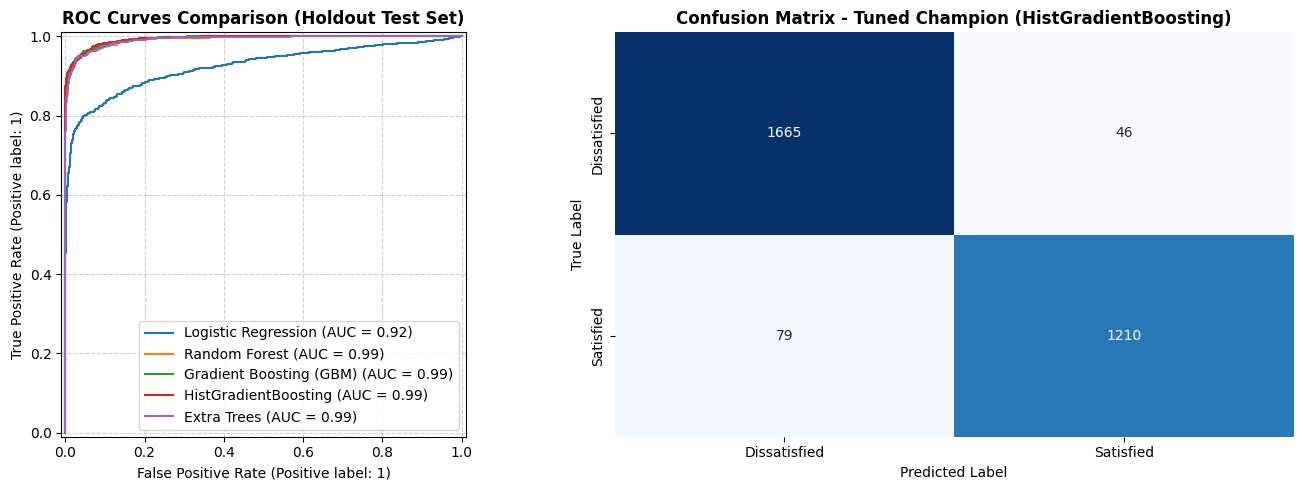

Champion pipeline (HistGradientBoosting) successfully exported to 'airline_satisfaction_champion.joblib'


In [10]:
plt.figure(figsize=(14, 5))

# Plot 1: ROC Curves of all benchmark models
ax1 = plt.subplot(1, 2, 1)
for name, pipe in fitted_pipelines.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, name=name, ax=ax1)
plt.title("ROC Curves Comparison (Holdout Test Set)", fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Confusion Matrix of the ACTUAL TUNED CHAMPION
ax2 = plt.subplot(1, 2, 2)
y_pred_champ = champion_pipeline.predict(X_test)
cm = confusion_matrix(y_test, y_pred_champ)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax2,
            xticklabels=['Dissatisfied', 'Satisfied'],
            yticklabels=['Dissatisfied', 'Satisfied'])
plt.title(f"Confusion Matrix - Tuned Champion ({champ_name})", fontsize=12, fontweight='bold')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# Save final pipeline for serving
joblib.dump(champion_pipeline, 'airline_satisfaction_champion.joblib')
print(f"Champion pipeline ({champ_name}) successfully exported to 'airline_satisfaction_champion.joblib'")

In [15]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

st.set_page_config(
    page_title="FlySense - Passenger Satisfaction Predictor",
    page_icon="✈️",
    layout="wide"
)

# Load the champion model pipeline
@st.cache_resource
def load_model():
    return joblib.load('airline_satisfaction_champion.joblib')

model = load_model()

st.title("✈️ Airline Passenger Satisfaction Prediction App")
st.markdown("Enter passenger flight and survey details below to predict their satisfaction rating.")

# Sidebar - Passenger & Flight Information
st.sidebar.header("📋 Passenger & Flight Info")
gender = st.sidebar.selectbox("Gender", ["Female", "Male"])
customer_type = st.sidebar.selectbox("Customer Type", ["Returning", "First-time"])
age = st.sidebar.slider("Age", 7, 85, 35)
type_of_travel = st.sidebar.selectbox("Type of Travel", ["Business", "Personal"])
travel_class = st.sidebar.selectbox("Class", ["Business", "Economy", "Economy Plus"])
flight_distance = st.sidebar.number_input("Flight Distance (miles)", min_value=50, max_value=5000, value=1200, step=50)
dep_delay = st.sidebar.number_input("Departure Delay (minutes)", min_value=0, max_value=1500, value=5, step=1)
arr_delay = st.sidebar.number_input("Arrival Delay (minutes)", min_value=0, max_value=1500, value=0, step=1)

# Main Form - Service & In-Flight Ratings
st.subheader("⭐ In-Flight & Touchpoint Ratings (1 = Poor, 5 = Excellent)")
col1, col2, col3 = st.columns(3)

with col1:
    wifi = st.slider("In-flight Wifi Service", 0, 5, 4)
    ease_booking = st.slider("Ease of Online Booking", 0, 5, 4)
    online_boarding = st.slider("Online Boarding", 0, 5, 4)
    gate_location = st.slider("Gate Location", 1, 5, 3)
    time_convenient = st.slider("Departure/Arrival Convenience", 0, 5, 4)

with col2:
    seat_comfort = st.slider("Seat Comfort", 1, 5, 4)
    leg_room = st.slider("Leg Room Service", 0, 5, 4)
    cleanliness = st.slider("Cleanliness", 0, 5, 4)
    food_drink = st.slider("Food and Drink", 0, 5, 3)

with col3:
    onboard_service = st.slider("On-board Service", 1, 5, 4)
    inflight_service = st.slider("In-flight Service", 1, 5, 4)
    inflight_ent = st.slider("In-flight Entertainment", 0, 5, 4)
    checkin_service = st.slider("Check-in Service", 1, 5, 4)
    baggage_handling = st.slider("Baggage Handling", 1, 5, 4)

# Predict Button
st.markdown("---")
if st.button("🚀 Predict Passenger Satisfaction", use_container_width=True):
    total_delay = dep_delay + arr_delay
    delay_ratio = total_delay / (flight_distance + 1)
    digital_exp = (ease_booking + online_boarding + wifi) / 3.0
    comfort_exp = (seat_comfort + leg_room + cleanliness) / 3.0

    input_data = pd.DataFrame([{
        "Gender": gender,
        "Age": age,
        "Customer Type": customer_type,
        "Type of Travel": type_of_travel,
        "Class": travel_class,
        "Flight Distance": flight_distance,
        "Departure Delay": dep_delay,
        "Arrival Delay": float(arr_delay),
        "Departure and Arrival Time Convenience": time_convenient,
        "Ease of Online Booking": ease_booking,
        "Check-in Service": checkin_service,
        "Online Boarding": online_boarding,
        "Gate Location": gate_location,
        "On-board Service": onboard_service,
        "Seat Comfort": seat_comfort,
        "Leg Room Service": leg_room,
        "Cleanliness": cleanliness,
        "Food and Drink": food_drink,
        "In-flight Service": inflight_service,
        "In-flight Wifi Service": wifi,
        "In-flight Entertainment": inflight_ent,
        "Baggage Handling": baggage_handling,
        "Total Delay": total_delay,
        "Delay Ratio": delay_ratio,
        "Digital Exp": digital_exp,
        "Comfort Exp": comfort_exp
    }])

    pred = model.predict(input_data)[0]
    prob = model.predict_proba(input_data)[0][1]

    res_col1, res_col2 = st.columns(2)
    with res_col1:
        if pred == 1:
            st.success("### 🎉 Prediction: Satisfied")
        else:
            st.error("### ⚠️ Prediction: Neutral or Dissatisfied")
    with res_col2:
        st.metric(label="Satisfaction Probability", value=f"{prob * 100:.2f}%")
        st.progress(float(prob))

Overwriting app.py


In [16]:
!pip install -q streamlit

import subprocess
import time
from google.colab.output import eval_js

# 1. Terminate any previous background streamlit servers
!pkill -f streamlit

# 2. Start Streamlit in the background
subprocess.Popen([
    "streamlit", "run", "app.py",
    "--server.port", "8501",
    "--server.headless", "true",
    "--server.enableCORS", "false",
    "--server.enableXsrfProtection", "false"
])

time.sleep(3)

# 3. Print the live, working URL
print("=" * 60)
print("👉 CLICK THIS LINK TO OPEN YOUR APP:")
print(eval_js("google.colab.kernel.proxyPort(8501)"))
print("=" * 60)

👉 CLICK THIS LINK TO OPEN YOUR APP:
https://8501-m-s-kkb-usc1b2-1730hyzq0zdl1-b.us-central1-2.prod.colab.dev
